In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler
import os
import globals as gl
from pcm_cortical import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
import pickle
import pingouin as pg

from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib import colormaps as cm
from Plot import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, set_spines_and_ticks_width, add_noise_ceiling, save_figure_incremental

plt.style.use('default')
plt.style.use('dark_background')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


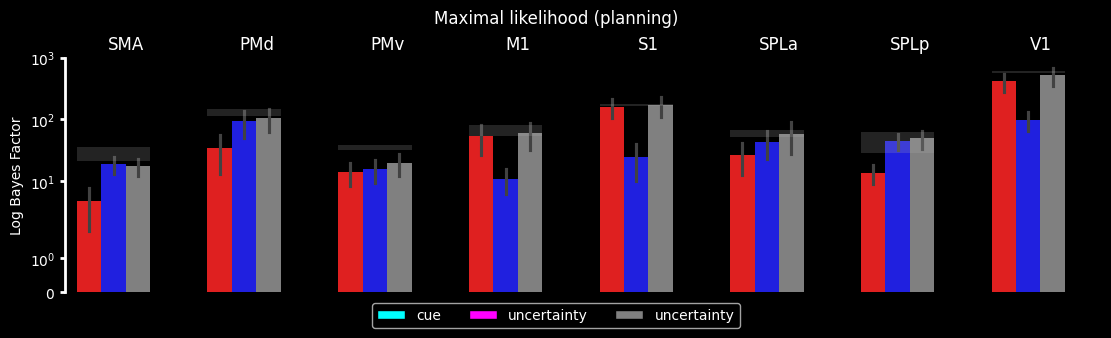

In [2]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

fig, axs = plt.subplots(1, len(rois), figsize=(11, 3), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette=['red', 'blue', 'grey'],
                    errorbar='se',
                    plottype='bar',
                    noise_ceil_col=[0.7, 0.7, 0.7, 0.2])

    ax.set_title(roi)
    ax.set_xlabel('')
    ax.set_ylim(0, 1000)
    ax.set_xlim(-1, 4)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params('y', width=2)

    if r == 0:
        ax.spines[['top', 'right', 'bottom']].set_visible(False)
        ax.spines[['left']].set_linewidth(2)
    else:
        ax.spines[['top', 'right','left', 'bottom']].set_visible(False)
        ax.spines[['bottom',]].set_bounds([0, 2])
        ax.tick_params(axis='y', width=0, which='both')

for ax in axs:
    ax.set_yscale('symlog')

fig.suptitle('Maximal likelihood (planning)')

# Define legend handles
legend_handles = [
    Patch(facecolor='cyan', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='uncertainty'),
    Patch(facecolor='grey', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=3,
           fontsize=10)

plt.show()

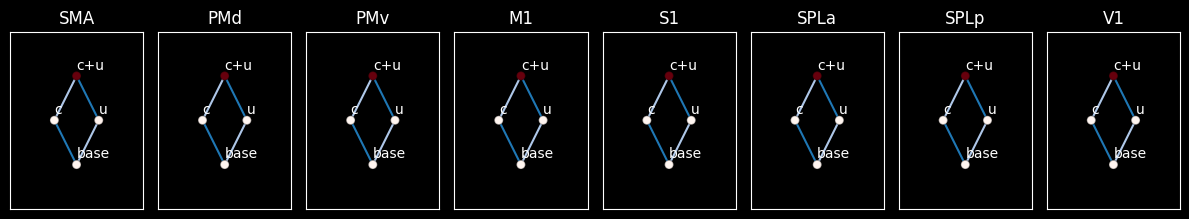

In [3]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

M = make_planning_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=['c', 'u'], basecomponents=None)

fig, axs = plt.subplots(1, len(rois), figsize=(12, 6))

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    mposterior = MF.model_posterior(T.likelihood.mean(axis=0),method='AIC',format='DataFrame')
    pcm.vis.plot_tree(MF,mposterior,show_labels=True,show_edges=True,model_size=.1)

    axs[r].set_aspect('equal')
    axs[r].set_title(roi)

fig.tight_layout()
plt.show()

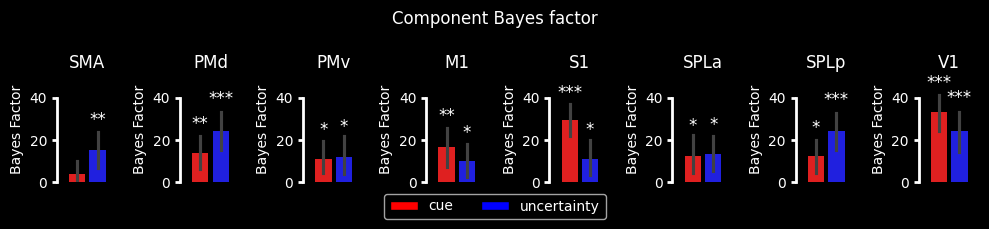

In [4]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

M = make_planning_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=['cue', 'uncertainty'], basecomponents=None)

fig, axs = plt.subplots(1, len(rois), figsize=(10, 2), sharex=True, constrained_layout=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf', palette=['red', 'blue'])

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0)

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
        bar_height = mean + ci

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].spines[['bottom', 'left',]].set_linewidth(2)
    axs[r].spines[['left',]].set_bounds([0, 40])
    axs[r].tick_params(width=2)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    axs[r].spines[['top', 'right','bottom']].set_visible(False)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    axs[r].set_title(roi)

for r in range(len(rois)):
    # axs[r].set_yscale('symlog')
    axs[r].set_ylim([0, 50])
    axs[r].set_xlim([-1, 2])

fig.suptitle('Component Bayes factor')


# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

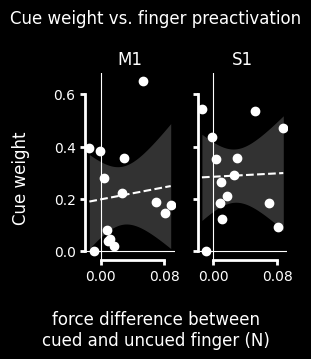

In [5]:
rois = ['M1', 'S1', ]
Hem = 'L'
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
experiment = 'smp2'
glm = 12

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

df = pd.DataFrame()
diff1, diff2, diff3 = np.zeros(len(snS)), np.zeros(len(snS)), np.zeros(len(snS))
for s, sn in enumerate(snS):
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])
    diff1[s] = (df[df['cue'] == 39]['index0'].mean() - df[df['cue'] == 93]['index0'].mean() +
                df[df['cue'] == 93]['ring0'].mean() - df[df['cue'] == 39]['ring0'].mean()) / 2
    diff3[s] = (df[df['stimFinger'] == 91999]['index1'].mean() - df[df['stimFinger'] == 99919]['index1'].mean() +
                df[df['stimFinger'] == 99919]['ring1'].mean() - df[df['stimFinger'] == 91999]['ring1'].mean()) / 2
    diff2[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(3, 3.5))

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    # Regression for diff2
    x = diff2
    y = theta_sqrt[0]
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = slope * x_fit + intercept

    # Compute confidence intervals
    n = len(x)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    dof = n - 2
    t_val = t.ppf(0.975, dof)

    se_line = np.sqrt(
        np.sum(residuals**2) / dof * (1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    )
    ci = t_val * se_line

    axs[r].plot(x_fit, y_fit, color='w', linestyle='--', label='Fit')
    axs[r].fill_between(x_fit, y_fit - ci, y_fit + ci, color='w', alpha=.2, label='95% CI', lw=0)
    axs[r].scatter(x, y, color='w')

    axs[r].axvline(0, lw=.8, color='w')
    axs[r].axhline(0, lw=.8, color='w')

    axs[r].set_title(roi)

    # Remove spines from 'left', 'top', and 'right'
    axs[r].spines['left'].set_bounds(0, .6)
    axs[r].spines['bottom'].set_bounds(0.0, .08)
    axs[r].spines['top'].set_visible(False)
    axs[r].spines['right'].set_visible(False)

    # Set ticks for x-axis and y-axis
    axs[r].set_xticks(np.linspace(0, .08, 2))
    axs[r].tick_params(width=2)

    # Set linewidth for remaining spines ('bottom') and ticks
    axs[r].spines['bottom'].set_linewidth(2)
    axs[r].spines['left'].set_linewidth(2)

fig.supxlabel('force difference between\ncued and uncued finger (N)')
fig.supylabel('Cue weight')

fig.suptitle('Cue weight vs. finger preactivation')

fig.tight_layout()


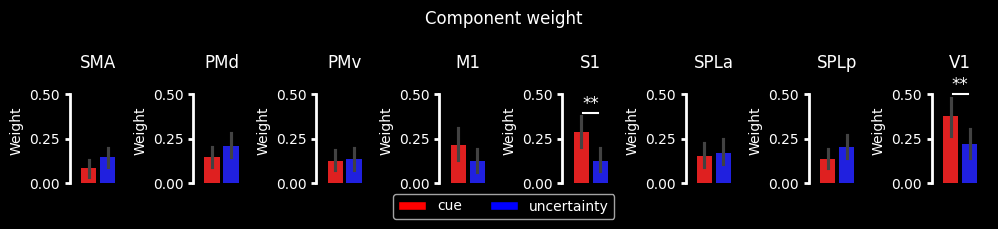

In [6]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

colors = sns.color_palette("Set3", n_colors=9) #+ [(.5, .5, .5)]
colors = [colors[2], colors[3], colors[8]]  # match color used for execution

fig, axs = plt.subplots(1, len(rois), figsize=(10, 2),sharex=True, constrained_layout=True)

for r, roi in enumerate(rois):

    # Bottom row: bar plot
    row_ax = axs[r]
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    df = pd.DataFrame(theta_sqrt.T, columns=features)

    sns.barplot(data=df, ax=row_ax, palette=['red', 'blue'])
    row_ax.set_xticks([])
    row_ax.set_title(roi)
    row_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    row_ax.set_xlim((-1, 2))
    row_ax.spines[['bottom',]].set_bounds(0, 1)
    row_ax.tick_params(width=2)
    row_ax.set_ylabel('Weight')
    if r == 0:

        row_ax.spines[['left',]].set_linewidth(2)
    else:
        row_ax.spines[['top', 'right','bottom']].set_visible(False)
        row_ax.spines[['left',]].set_linewidth(2)

    a = df['cue']
    b = df['uncertainty']

    _, p_val_paired = ttest_rel(a, b)

    # Significance stars
    if p_val_paired < 0.001:
        stars = '***'
    elif p_val_paired < 0.01:
        stars = '**'
    elif p_val_paired < 0.05:
        stars = '*'
    else:
        stars = None

    if stars:
        # Estimate max height for the bar
        y_max = row_ax.get_ylim()[1]

        # Compute x positions of the bars for the two models
        center = .5
        x1 = center - .4   # component
        x2 = center + .4   # feature

        # Draw bar and stars
        row_ax.plot([x1, x2], [y_max, y_max], lw=1.5, c='w')
        row_ax.text((x1 + x2) / 2, y_max, stars, ha='center', va='bottom', fontsize=12)

    row_ax.set_ylim((-.01, .6))
    row_ax.spines[['left',]].set_bounds(0, .5)

fig.suptitle('Component weight')

# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

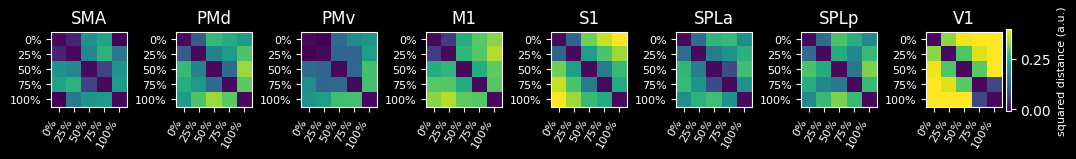

In [7]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['cue', 'uncertainty'])
x_pos = [0, 1.5, 2.5, 4, 5.5, 7]

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

vmin, vmax = -.01, .4

colors = sns.color_palette("Set3", n_colors=9) #+ [(.5, .5, .5)]
colors = [colors[2], colors[3], colors[8]]  # match color used for execution

fig, axs = plt.subplots(1, len(rois), figsize=(10, 2),sharex=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs)
    D_obs = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(5))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    # if r==0:
    im_ax.set_yticks(np.arange(5))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)

# fig.subplots_adjust(right=0.92)
bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)

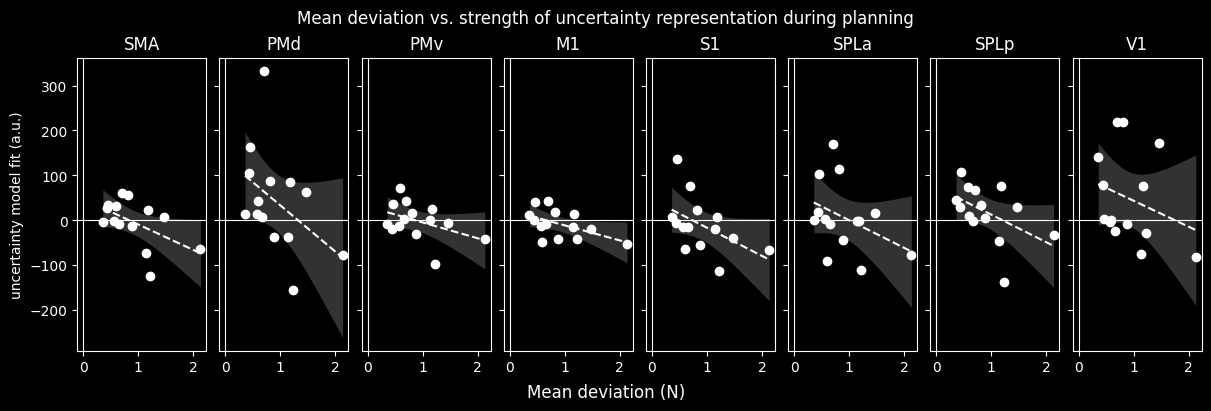

In [8]:
glm = 12
H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
experiment = 'smp2'

snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]

df = pd.DataFrame()
for sn in snS:
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])
df.stimFinger = df.stimFinger.map(gl.stimFinger_mapping)
df.cue = df.cue.map(gl.cue_mapping)
df = df[((df.stimFinger=='index') & (df.cue=='75%')) | ((df.stimFinger=='ring') & (df.cue=='25%'))]
df = df.groupby(['sn']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 4), constrained_layout=True)

for r, roi in enumerate(rois):
    T_in = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.plan.glm{glm}.{H}.{roi}.p'))

    x = df['MD']
    y = T_in['likelihood']['uncertainty'] - T_in['likelihood']['null']
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = slope * x_fit + intercept

    # Compute confidence intervals
    n = len(x)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    dof = n - 2
    t_val = t.ppf(0.975, dof)

    se_line = np.sqrt(
        np.sum(residuals**2) / dof * (1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    )
    ci = t_val * se_line

    ax = axs[r]
    ax.plot(x_fit, y_fit, color='w', linestyle='--', label='Fit')
    ax.fill_between(x_fit, y_fit - ci, y_fit + ci, color='w', alpha=.2, label='95% CI', lw=0)
    ax.scatter(x, y, color='w')

    ax.axvline(0, lw=.8, color='w')
    ax.axhline(0, lw=.8, color='w')

    ax.set_title(roi)

axs[0].set_ylabel('uncertainty model fit (a.u.)')
fig.supxlabel(f'Mean deviation (N)')
fig.suptitle('Mean deviation vs. strength of uncertainty representation during planning')
plt.show()

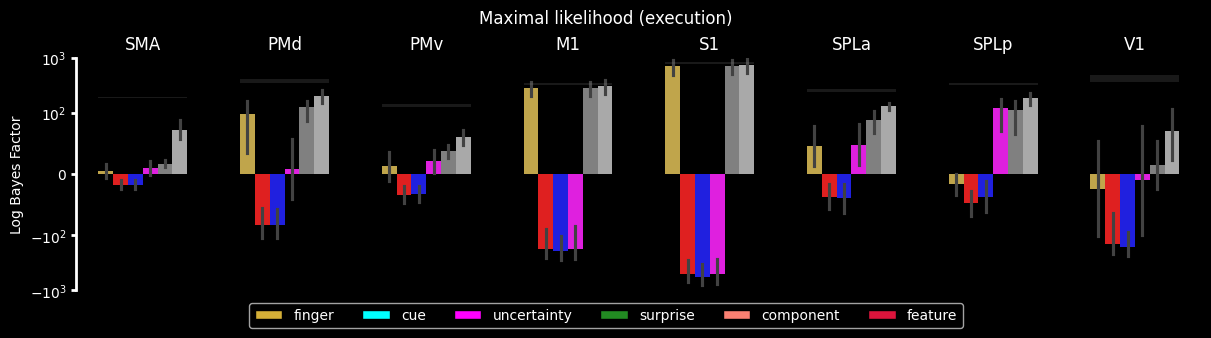

In [9]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'feature')

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3), sharex=True, sharey=True, constrained_layout=True)

colors = sns.color_palette("Reds", n_colors=5)

for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{Hem}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{Hem}.{roi}.p'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette=['#D4AF37', 'red', 'blue', 'magenta', 'grey', 'darkgrey'],
                    errorbar='se',
                    plottype='bar')

    ax.set_title(roi)
    ax.set_xlabel('')
    # ax.set_ylim(-1, 2 * 10**3)
    ax.set_xlim(-2, 7)
    ax.set_ylim(-1000, 1000)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params('y', width=2)

    if r == 0:
        ax.spines[['top', 'right', 'bottom']].set_visible(False)
        ax.spines[['left']].set_linewidth(2)
        # ax.spines[['left',]].set_bounds([0, 1000])
        # ax.spines[['bottom',]].set_bounds([0, 2])
    else:
        ax.spines[['top', 'right','left', 'bottom']].set_visible(False)
        # ax.spines[['bottom']].set_linewidth(2)
        ax.spines[['bottom',]].set_bounds([0, 2])
        ax.tick_params(axis='y', width=0, which='both')

for ax in axs:
    ax.set_yscale('symlog', linthresh=100)

fig.suptitle('Maximal likelihood (execution)')

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='uncertainty'),
    Patch(facecolor='forestgreen', edgecolor='black', label='surprise'),
    Patch(facecolor='salmon', edgecolor='black', label='component'),
    Patch(facecolor='crimson', edgecolor='black', label='feature')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=6,
           fontsize=10)


plt.show()

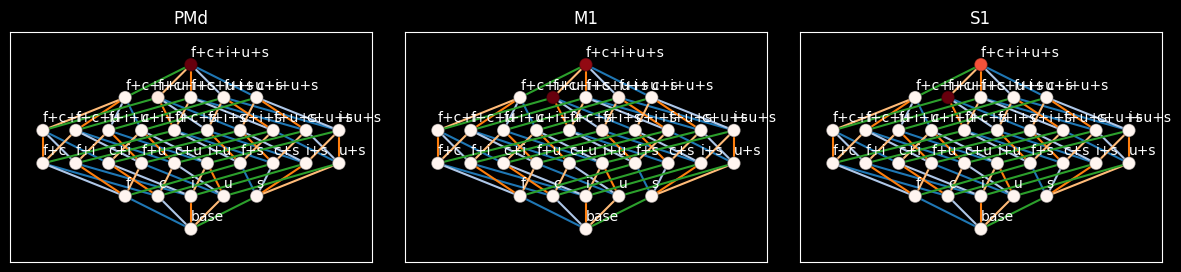

In [10]:
rois = ['PMd', 'M1', 'S1']
glm = 12
H = 'L'
experiment = 'smp2'

components = ['f', 'c', 'i', 'u', 's']

M = make_execution_models()
M, _ = find_model(M, 'feature')
MF = pcm.model.ModelFamily(M, comp_names=components,)

fig, axs = plt.subplots(1, len(rois), figsize=(12, 6))

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    # pcm.vis.model_plot(T.likelihood-MF.num_comp_per_m)
    mposterior = MF.model_posterior(T.likelihood.mean(axis=0),method='AIC',format='DataFrame')
    pcm.vis.plot_tree(MF,mposterior,show_labels=True,show_edges=True,model_size=.2)

    axs[r].set_aspect('equal')
    axs[r].set_title(roi)

fig.tight_layout()
plt.show()

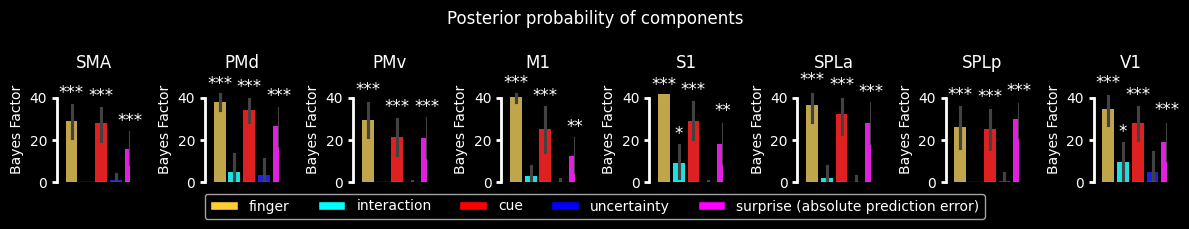

In [11]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = ['finger', 'cue', 'interaction', 'uncertainty', 'surprise']

M = make_execution_models()
M, _ = find_model(M, 'feature')
MF = pcm.model.ModelFamily(M, comp_names=components,)

fig, axs = plt.subplots(1, len(rois), figsize=(12, 2),  constrained_layout=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    # pcm.vis.model_plot(T.likelihood-MF.num_comp_per_m)
    # cposterior = MF.component_posterior(T.likelihood.mean(axis=0),method='AIC',format='DataFrame')
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'cyan','red', 'blue', 'magenta'])

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
        bar_height = mean + ci

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].set_title(roi)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(components, rotation=60, ha='right')
    axs[r].hlines(0, 0, 4, color='w', lw=0.8)
    axs[r].spines[['top', 'right', 'bottom']].set_visible(False)
    axs[r].spines[['left', ]].set_bounds(0, 40)
    axs[r].spines[['left', ]].set_linewidth(2)
    # axs[r].set_yticks([-.5, 0, 1, 2])
    axs[r].set_xlim([-1, 4])
    axs[r].set_ylim([0, 50])
    axs[r].spines[['bottom',]].set_bounds(0, 5)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    axs[r].tick_params(width=2)

# Define legend handles
legend_handles = [
    Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (absolute prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=6,
           fontsize=10)

fig.suptitle('Posterior probability of components')

fig.tight_layout()

plt.show()

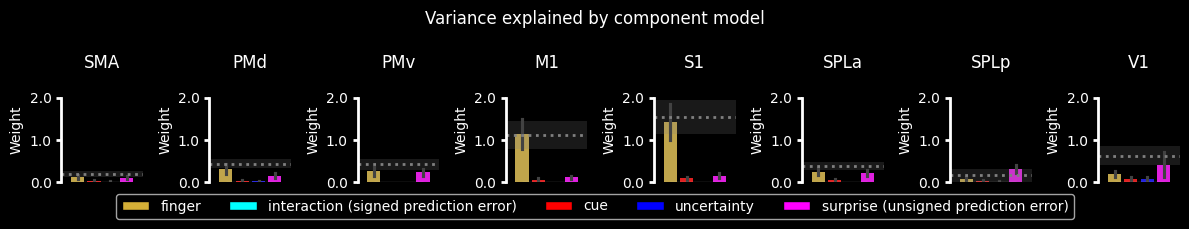

In [13]:
brois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['finger', 'cue', 'uncertainty', 'surprise'])
x_pos = [0, 1.5, 2.5, 4, 5.5, 7]

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'component')
n_param = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(12, 2))

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    row_ax = axs[r]
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    var_expl = np.exp(theta)

    sns.barplot(data=var_expl.T, ax=row_ax, palette=['#D4AF37', 'red', 'blue', 'magenta'], errorbar='se')

    row_ax.set_title(roi)
    row_ax.set_xticks(row_ax.get_xticks())
    row_ax.set_xticklabels(features, rotation=60, ha='right')
    row_ax.hlines(0, 0, 3, color='w', lw=0.8)
    row_ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    row_ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    row_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    row_ax.spines[['left', ]].set_bounds(0, 2)
    row_ax.spines[['left', ]].set_linewidth(2)
    row_ax.set_yticks([-.5, 0, 1, 2])
    row_ax.set_xlim((-1, 4))
    row_ax.set_ylim((0, 2.5))
    row_ax.spines[['bottom',]].set_bounds(0, 4)
    row_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    row_ax.set_ylabel('Weight')
    row_ax.tick_params(width=2)
    row_ax.spines[['top', 'right', 'bottom']].set_visible(False)

    _, p_val_1samp = ttest_1samp(var_expl[1], 0, alternative='two-sided')

    n = len(var_expl[1])
    mean = np.abs(var_expl[1].mean())
    sem = var_expl[1].std(ddof=1) / (n**0.5)
    ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
    bar_height = np.sign(var_expl[1].mean()) * (mean + ci) * 1.1

    if p_val_1samp < 0.001:
        stars = '***'
    elif p_val_1samp < 0.01:
        stars = '**'
    elif p_val_1samp < 0.05:
        stars = '*'
    else:
        stars = str(p_val_1samp)

    # if stars:
    #     axs[r].text(1, bar_height, stars, ha='center', va='top', fontsize=12)

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=6,
           fontsize=10)
fig.suptitle('Variance explained by component model')

fig.tight_layout()

plt.show()

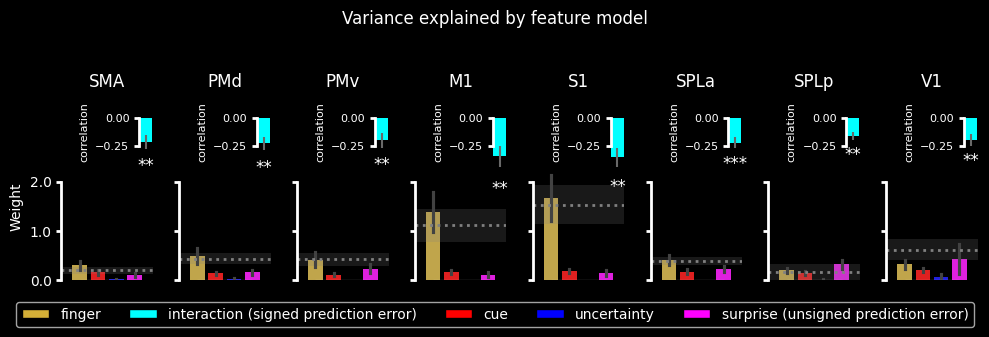

In [14]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['finger', 'cue', 'uncertainty', 'surprise'])
x_pos = [0, 1.5, 2.5, 4, 5.5, 7]

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'feature')

Ac = Mf.Ac.sum(axis=0)
n_param = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(10, 3), sharey=True)

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    row_ax = axs[r]
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta2 = theta**2
    # var_expl = np.vstack([theta2[0,:] + theta2[1,:], theta[1,:] * theta[2,:], theta2[2,:] + theta2[3,:], theta2[4,:], theta2[5,:]])
    var_expl = np.vstack([theta2[0,:],
                          theta2[1,:] + theta2[2,:],
                          theta2[3,:], theta2[4,:]])

    sns.barplot(data=var_expl.T, ax=row_ax, palette=['#D4AF37', 'red', 'blue', 'magenta'], errorbar='se')

    inset_ax = row_ax.inset_axes([.85, .75, .15, .5], transform=row_ax.transAxes)
    interaction = theta[0,:] * theta[2,:]
    inset_ax.bar(0, interaction.mean(), width=.5, facecolor='cyan', yerr=interaction.std() / np.sqrt(len(interaction)), ecolor='dimgrey')
    # inset_ax.set_xlim(-1, 1)
    inset_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    inset_ax.spines[['left', ]].set_linewidth(2)
    inset_ax.spines[['left', ]].set_bounds(-.25, 0)
    inset_ax.set_ylabel('correlation', fontsize=8)
    inset_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    inset_ax.tick_params(axis='y', width=2, labelsize=8)
    inset_ax.set_ylim(-.45, .2)

    row_ax.set_title(roi)
    row_ax.set_xticks(row_ax.get_xticks())
    row_ax.set_xticklabels(features, rotation=60, ha='right')
    row_ax.hlines(0, 0, 3, color='w', lw=0.8)
    row_ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    row_ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    row_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    row_ax.spines[['left', ]].set_bounds(0, 2)
    row_ax.spines[['left', ]].set_linewidth(2)
    row_ax.set_yticks([-.5, 0, 1, 2])
    row_ax.set_xlim((-1, 4))
    row_ax.set_ylim((0, 3))
    row_ax.spines[['bottom',]].set_bounds(0, 4)
    row_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    row_ax.set_ylabel('Weight')
    row_ax.tick_params(width=2)
    row_ax.spines[['top', 'right', 'bottom']].set_visible(False)

    _, p_val_1samp = ttest_1samp(interaction, 0, alternative='two-sided')

    n = len(interaction)
    mean = np.abs(interaction.mean())
    sem = interaction.std(ddof=1) / (n**0.5)
    ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
    bar_height = np.sign(interaction.mean()) * (mean + ci) * 1

    if p_val_1samp < 0.001:
        stars = '***'
    elif p_val_1samp < 0.01:
        stars = '**'
    elif p_val_1samp < 0.05:
        stars = '*'
    else:
        stars = str(p_val_1samp)

    if stars:
        inset_ax.text(0, bar_height, stars, ha='center', va='top', fontsize=12)

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=6,
           fontsize=10)
fig.suptitle('Variance explained by feature model')

fig.tight_layout()

plt.show()

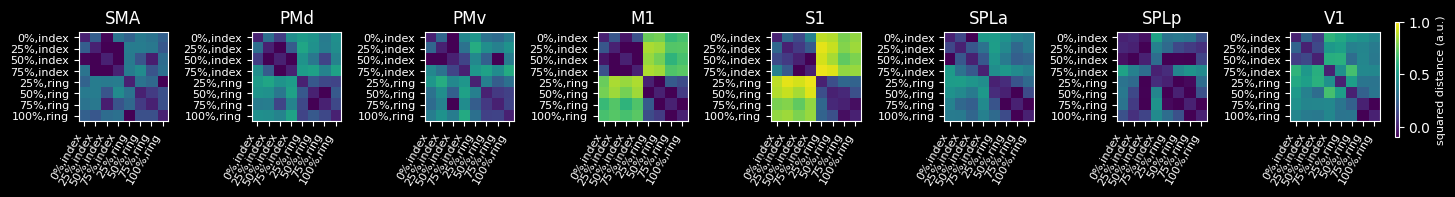

In [15]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

vmin, vmax = -.1, 1

fig, axs = plt.subplots(1, len(rois), figsize=(14, 6),)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    G_obs_avg = G_obs.mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs_avg)
    D_obs = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax, cmap='viridis')
    im_ax.set_xticks(np.arange(8))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    im_ax.set_yticks(np.arange(8))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.0025, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)
fig.tight_layout()